# ENVIRONMENTAL DATA OVERVIEW
This notebook aims to explore the environmental data and prepare it for further analysis and machine learning.

Firstly, we want to make sure we are using the correct environment for python and that all libraries that are needed are imported.

## Libraies

In [ ]:
import sys
print(sys.executable)

In [2]:
#we import all they key libraries needed in this notebook
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib as matplotlib

## Functions

In [3]:
#how deep do we want to look into environmental data. Higher values mean more processing time
desired_depth = 50

In [4]:
from format import removeEmptyRows, removeRed, objToNum, filterDepth, roundCoord
from visualize import plotColsOnMap

## Net CDF data files of $O_2$, $N$, $P$, $Temp$ and visualizations on earth map

### IMPORTANT
Files needed in ./nc/otpn/ folder:
- ***woa23_all_o00_01.nc***
- ***woa23_decav_t00_01.nc***
- ***woa23_all_p00_01.nc***
- ***woa23_all_n00_01.n***

If repo was cloned they are already there and nothing needs to be done. Same for other input files.


In [5]:
#paths to the net CDF files that should be sotred in the ./nc folder
mapsnc = {
    "o": "woa23_all_o00_01.nc",
    "t": "woa23_decav_t00_01.nc",
    "p": "woa23_all_p00_01.nc",
    "n":"woa23_all_n00_01.nc"
}

mapsds = dict()
#we can open each file
for feature, path in mapsnc.items():
    temp_ds = xr.open_dataset("../nc/otpn/"+path, decode_times=False)
    mapsds[feature] = temp_ds

#### Plotting the data
Plot the data on a map and average the depth until the desired depth set above.

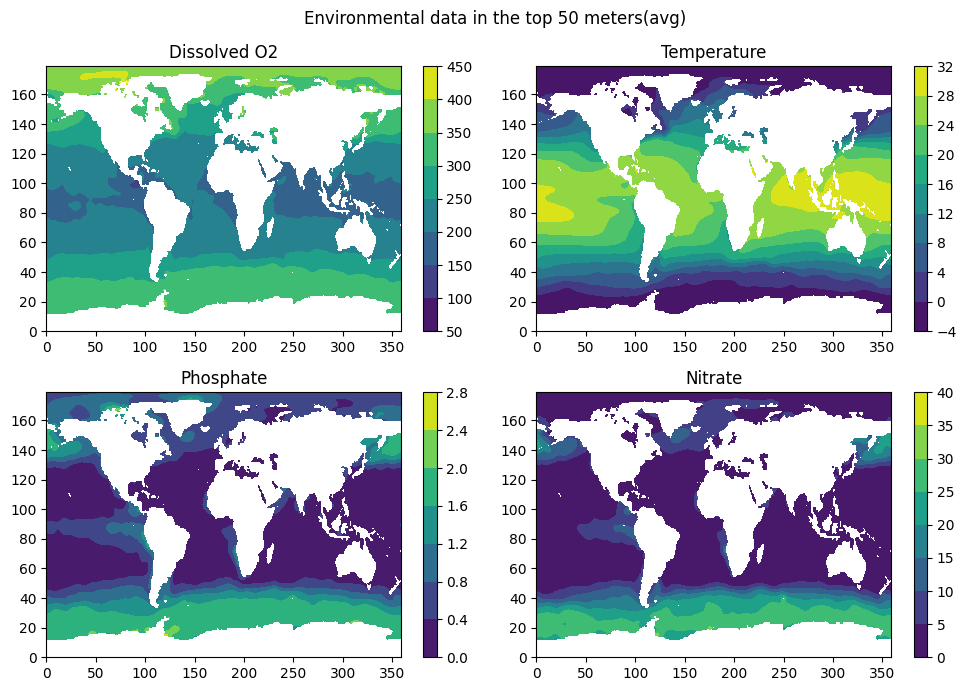

In [6]:
#the plot and plot data for visualization
figure, axis = plt.subplots(2, 2, figsize = (10,7))
map_plot_data = {
    "o": ("Dissolved O2", (0,0)),
    "t": ("Temperature", (0,1)),
    "p": ("Phosphate", (1,0)),
    "n": ("Nitrate", (1,1))
}

#we want to average out the data according to the depth in the desired range
for feature, feat_ds in mapsds.items():
    mapsds[feature] = feat_ds['{0}_an'.format(feature)].sel(depth=slice(0, desired_depth)).isel(time=0).mean(dim='depth')

    #then the data can be plotted
    title = map_plot_data[feature][0]
    x,y = map_plot_data[feature][1][0],map_plot_data[feature][1][1]
    col = axis[x,y].contourf(mapsds[feature])
    axis[x,y].set_title(title)
    #adding the colorbar
    figure.colorbar(col, ax=axis[x,y], orientation='vertical')

figure.suptitle("Environmental data in the top {0} meters(avg)".format(desired_depth))
plt.tight_layout()
plt.show()

#### Prepare the dataset for training

Here datasets are opened but the depth is not averaged to be more benefitial for the trainign and to allow for wider range of environmental conditions.

In [7]:
otpn_dfs = []

#we can open each file and format the net cdf file into a pandas dataframe
for feature, path in mapsnc.items():
    #columns to keep
    keepers = ["lat","lon","depth", feature+"_an"]

    temp_ds = xr.open_dataset("../nc/otpn/"+path, decode_times=False).sel(depth=slice(0, desired_depth))
    #rename the columns
    new_names = {'lat': 'LATITUDE', 'lon': 'LONGITUDE','depth': "DEPTH (m)" ,feature+"_an": feature.upper()}

    #converting the dataframe and renaming
    temp_df = temp_ds.to_dataframe().reset_index()[keepers]
    temp_df.rename(columns=new_names, inplace = True)

    #rounding the coordinates
    coords = ['LATITUDE','LONGITUDE', "DEPTH (m)"]
    temp_df_rnd = roundCoord([feature.upper()], temp_df, coords)

    otpn_dfs.append(temp_df_rnd.set_index(coords))

#the final results are joined together
otpn_df = removeEmptyRows(["O","T","P","N"],pd.concat(otpn_dfs, axis=1).reset_index())
otpn_df.rename(columns={"O":"O2"}, inplace=True)

print(otpn_df.head())
print(otpn_df.info())
print(otpn_df.describe())

#results are saved
otpn_df.to_csv("../csv/features/OTPN.csv", index=False)

       LATITUDE  LONGITUDE  DEPTH (m)          O2        T         P  \
95051       -78       -178          0  327.145569 -1.39071  1.585354   
95052       -78       -178          5  323.660980 -1.39741  1.564636   
95053       -78       -178         10  322.859222 -1.42181  1.587365   
95054       -78       -178         15  321.844238 -1.43271  1.587337   
95055       -78       -178         20  320.227783 -1.42881  1.598962   

               N  
95051  19.783365  
95052  19.997166  
95053  20.630762  
95054  20.905594  
95055  20.937330  
<class 'pandas.DataFrame'>
Index: 898730 entries, 95051 to 1425599
Data columns (total 7 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   LATITUDE   898730 non-null  int64  
 1   LONGITUDE  898730 non-null  int64  
 2   DEPTH (m)  898730 non-null  int64  
 3   O2         898730 non-null  float32
 4   T          898730 non-null  float32
 5   P          898730 non-null  float32
 6   N          898730 non

## Solar radiation data
[ERA5 monthly averaged data on single levels from 1940 to present](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-monthly-means?tab=overview) is the source for this data, in terms of exact features chosen in the request for the data the following were selected:
- **Product type:** 
Monthly averaged reanalysis
- **Mean rates:** Mean surface downward long-wave radiation flux
- **Months:** all months
- **Year**: 2024
- **Time** 00:00 - the only available option

In [8]:
solar_source = xr.open_dataset("../nc/radiation/data_stream-moda_stepType-avgad2.nc")
solar_feat = "avg_sdlwrf"
print(solar_source)

<xarray.Dataset> Size: 50MB
Dimensions:     (valid_time: 12, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 96B 2024-01-01T06:00:00 ... 2024-...
    expver      (valid_time) <U4 192B ...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number      int64 8B ...
Data variables:
    avg_sdlwrf  (valid_time, latitude, longitude) float32 50MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-07-08T14:09 GRIB to CDM+CF via cfgrib-0.9.1...


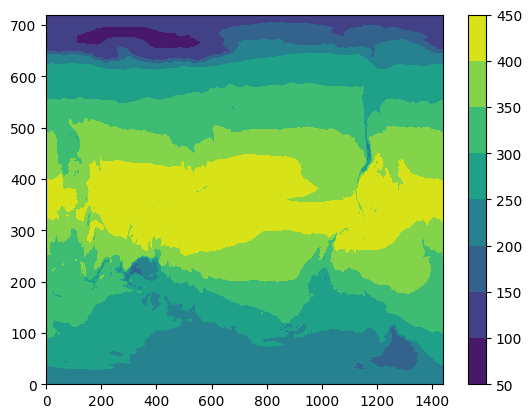

In [9]:
source_m = solar_source[solar_feat].mean(dim="valid_time")
#then the data can be plotted
title = "testplot"
col = plt.contourf(source_m)
#adding the colorbar
plt.colorbar(col, orientation='vertical')
plt.show()

We need to convert the net cdf dataset into a pandas dataframe. After seeing the info we can tell that there are no null datapoints so the step of dropping them can be skipped.

In [10]:
solar_df = source_m.to_dataframe().reset_index()
#we select only specific columns to keep
solar_cols = ['latitude', 'longitude', 'avg_sdlwrf']
solar_df = solar_df[solar_cols]
#the dataframe info is printed
solar_df.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 1038240 entries, 0 to 1038239
Data columns (total 3 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   latitude    1038240 non-null  float64
 1   longitude   1038240 non-null  float64
 2   avg_sdlwrf  1038240 non-null  float32
dtypes: float32(1), float64(2)
memory usage: 19.8 MB


We can tell that longitude is a float value along with the latitude. However, what can cause issues in the future the most is longitude being from 0 to 360 instead of the normal -180 to 180. So, the next steps are:
1. rounding up the coordinates
2. averaging data at the same point
3. renaming columns
4. converting the longitude range to the standard one

In [11]:
solar_df.describe()

,latitude,longitude,avg_sdlwrf
count,1.038240e+06,1.038240e+06,1.038240e+06
mean,0.000000e+00,1.798750e+02,3.062651e+02
std,5.203367e+01,1.039231e+02,8.614235e+01
min,-9.000000e+01,0.000000e+00,8.667115e+01
25%,-4.500000e+01,8.993750e+01,2.465943e+02
50%,0.000000e+00,1.798750e+02,3.133072e+02
75%,4.500000e+01,2.698125e+02,3.795618e+02
max,9.000000e+01,3.597500e+02,4.396080e+02


In [12]:
solar_df_rnd = roundCoord(["avg_sdlwrf"],solar_df, ['latitude','longitude'])
solar_df_rnd.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 1038240 entries, 0 to 1038239
Data columns (total 3 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   latitude    1038240 non-null  int64  
 1   longitude   1038240 non-null  int64  
 2   avg_sdlwrf  1038240 non-null  float32
dtypes: float32(1), int64(2)
memory usage: 19.8 MB


We need to average data at each point and rename columns to fit the standard that is expected later.

In [13]:
solar_df_avg = solar_df_rnd.groupby(['latitude', 'longitude']).mean().reset_index()
solar_df_avg.rename(columns={'latitude':"LATITUDE","longitude":"LONGITUDE"}, inplace=True)
solar_df_avg.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 65341 entries, 0 to 65340
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   LATITUDE    65341 non-null  int64  
 1   LONGITUDE   65341 non-null  int64  
 2   avg_sdlwrf  65341 non-null  float32
dtypes: float32(1), int64(2)
memory usage: 1.2 MB


This is a scatter plot with the results of the transformations applied.

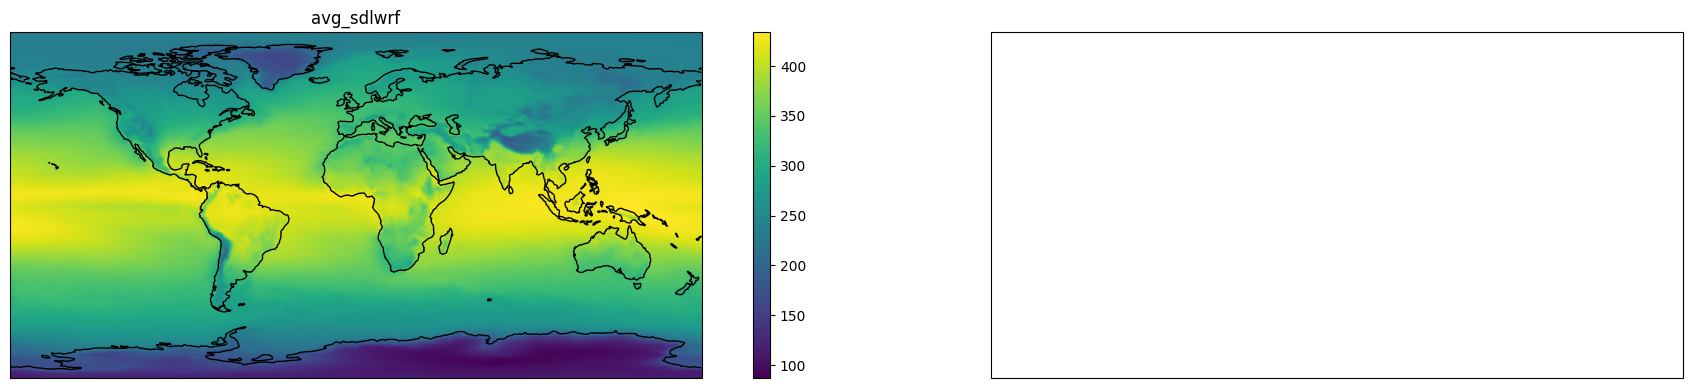

In [14]:
plotColsOnMap([solar_feat], solar_df_avg, constant=1)

Here the range conversion is applied.

In [15]:
conversion_mask = solar_df_avg["LONGITUDE"]>=180
solar_df_avg.loc[conversion_mask, "LONGITUDE"]=solar_df_avg["LONGITUDE"][conversion_mask]-np.ones(len(solar_df_avg["LONGITUDE"][conversion_mask]))*360
solar_df_avg.describe()

,LATITUDE,LONGITUDE,avg_sdlwrf
count,65341.000000,65341.000000,65341.000000
mean,0.000000,-0.498615,305.732849
std,52.249802,103.779408,86.389252
min,-90.000000,-180.000000,86.939529
25%,-45.000000,-90.000000,245.611923
50%,0.000000,0.000000,312.778198
75%,45.000000,89.000000,379.216919
max,90.000000,179.000000,433.933319


Not all radiation can be used by the bacteria and plants for photosynthesis so we need to take the 45% percent to get the approximate amount of energy that they can use.

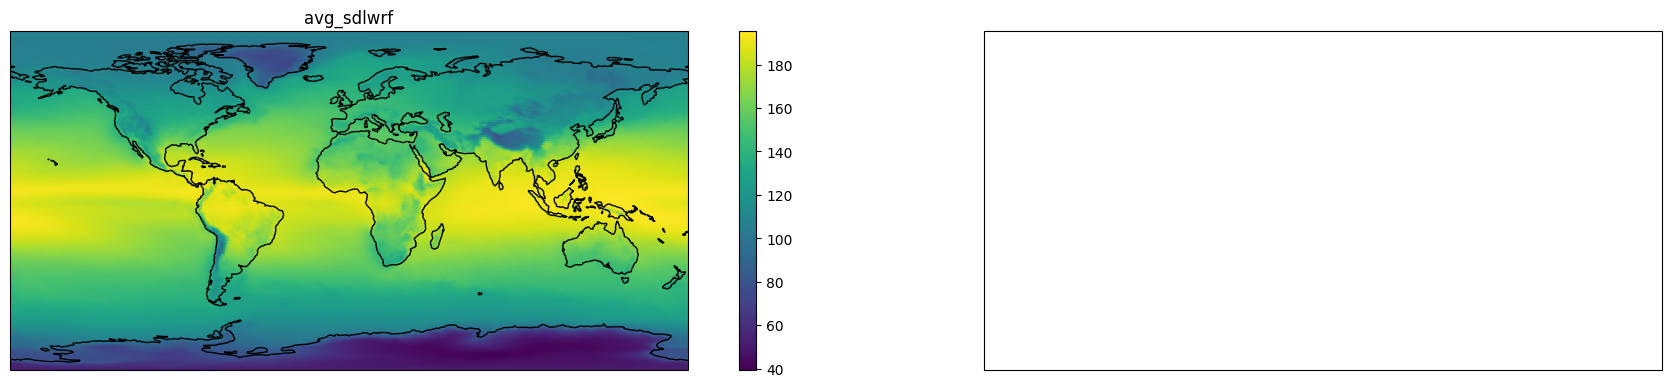

In [16]:
solar_df_avg[solar_feat] = solar_df_avg[solar_feat]*0.45
plotColsOnMap([solar_feat], solar_df_avg, constant=1)

The data column is renamed to simplify further work with it.

In [17]:
solar_df_avg.rename(columns={solar_feat:"solar"}, inplace=True)
solar_df_avg.to_csv("../csv/features/solar.csv", index=False)

## Fe net CDF files

So, unlike other environmental data the data for Fe comes from a different source and requires different kind of transformation that is done in this section.

### IMPORTANT:
Thse files have to be present in the ./nc/Fe folder for the following code to work. But as above they are already included in the repo. 

- ***k7oda_dfe_clim0100_04a.nc***
- ***k7oda_dfe_clim0200_04a.nc***
- ***k7oda_dfe_clim0300_04a.nc***
- ***k7oda_dfe_clim0400_04a.nc***
- ***k7oda_dfe_clim0500_04a.nc***
- ***k7oda_dfe_clim0600_04a.nc***
- ***k7oda_dfe_clim0700_04a.nc***
- ***k7oda_dfe_clim0800_04a.nc***
- ***k7oda_dfe_clim0900_04a.nc***
- ***k7oda_dfe_clim1000_04a.nc***
- ***k7oda_dfe_clim1100_04a.nc***
- ***k7oda_dfe_clim1200_04a.nc***

The first step is to visualize the data and see how it changes as we don't know the contents of the net CDF files yet.

In [18]:
#we open all files one by one and store them in an array
Fe_array =[]
for i in range(1,13):
    num = str(i) if len(str(i))==2 else "0"+str(i)

    path = "../nc/Fe/k7oda_dfe_clim"+num+"00_04a.nc"
    arr = xr.open_dataset(path, decode_times=False)
    Fe_array.append(arr)

print(Fe_array[0])
print(Fe_array[0]["dFe"])

<xarray.Dataset> Size: 10MB
Dimensions:    (TIME: 1, DEPTH: 46, LATITUDE: 155, LONGITUDE: 360)
Coordinates:
  * TIME       (TIME) int32 4B 961
  * DEPTH      (DEPTH) float32 184B 5.0 15.0 25.0 ... 5.262e+03 5.525e+03
  * LATITUDE   (LATITUDE) float32 620B -74.5 -73.5 -72.5 ... 77.5 78.5 79.5
  * LONGITUDE  (LONGITUDE) float32 1kB 0.5 1.5 2.5 3.5 ... 357.5 358.5 359.5
Data variables:
    dFe        (TIME, DEPTH, LATITUDE, LONGITUDE) float32 10MB ...
Attributes:
    description:  K7 ODA Monthly Mean
<xarray.DataArray 'dFe' (TIME: 1, DEPTH: 46, LATITUDE: 155, LONGITUDE: 360)> Size: 10MB
[2566800 values with dtype=float32]
Coordinates:
  * TIME       (TIME) int32 4B 961
  * DEPTH      (DEPTH) float32 184B 5.0 15.0 25.0 ... 5.262e+03 5.525e+03
  * LATITUDE   (LATITUDE) float32 620B -74.5 -73.5 -72.5 ... 77.5 78.5 79.5
  * LONGITUDE  (LONGITUDE) float32 1kB 0.5 1.5 2.5 3.5 ... 357.5 358.5 359.5
Attributes:
    units:      nano mol/L
    long_name:  Dissolved iron


The data for Iron is organized by month. The next step after loading is to visualize it to see what we are dealing with in terms of area coverage and ranges. The viusalization is using the averaged data at each coordinate, while the real data has a 3d dimenstion of depth.

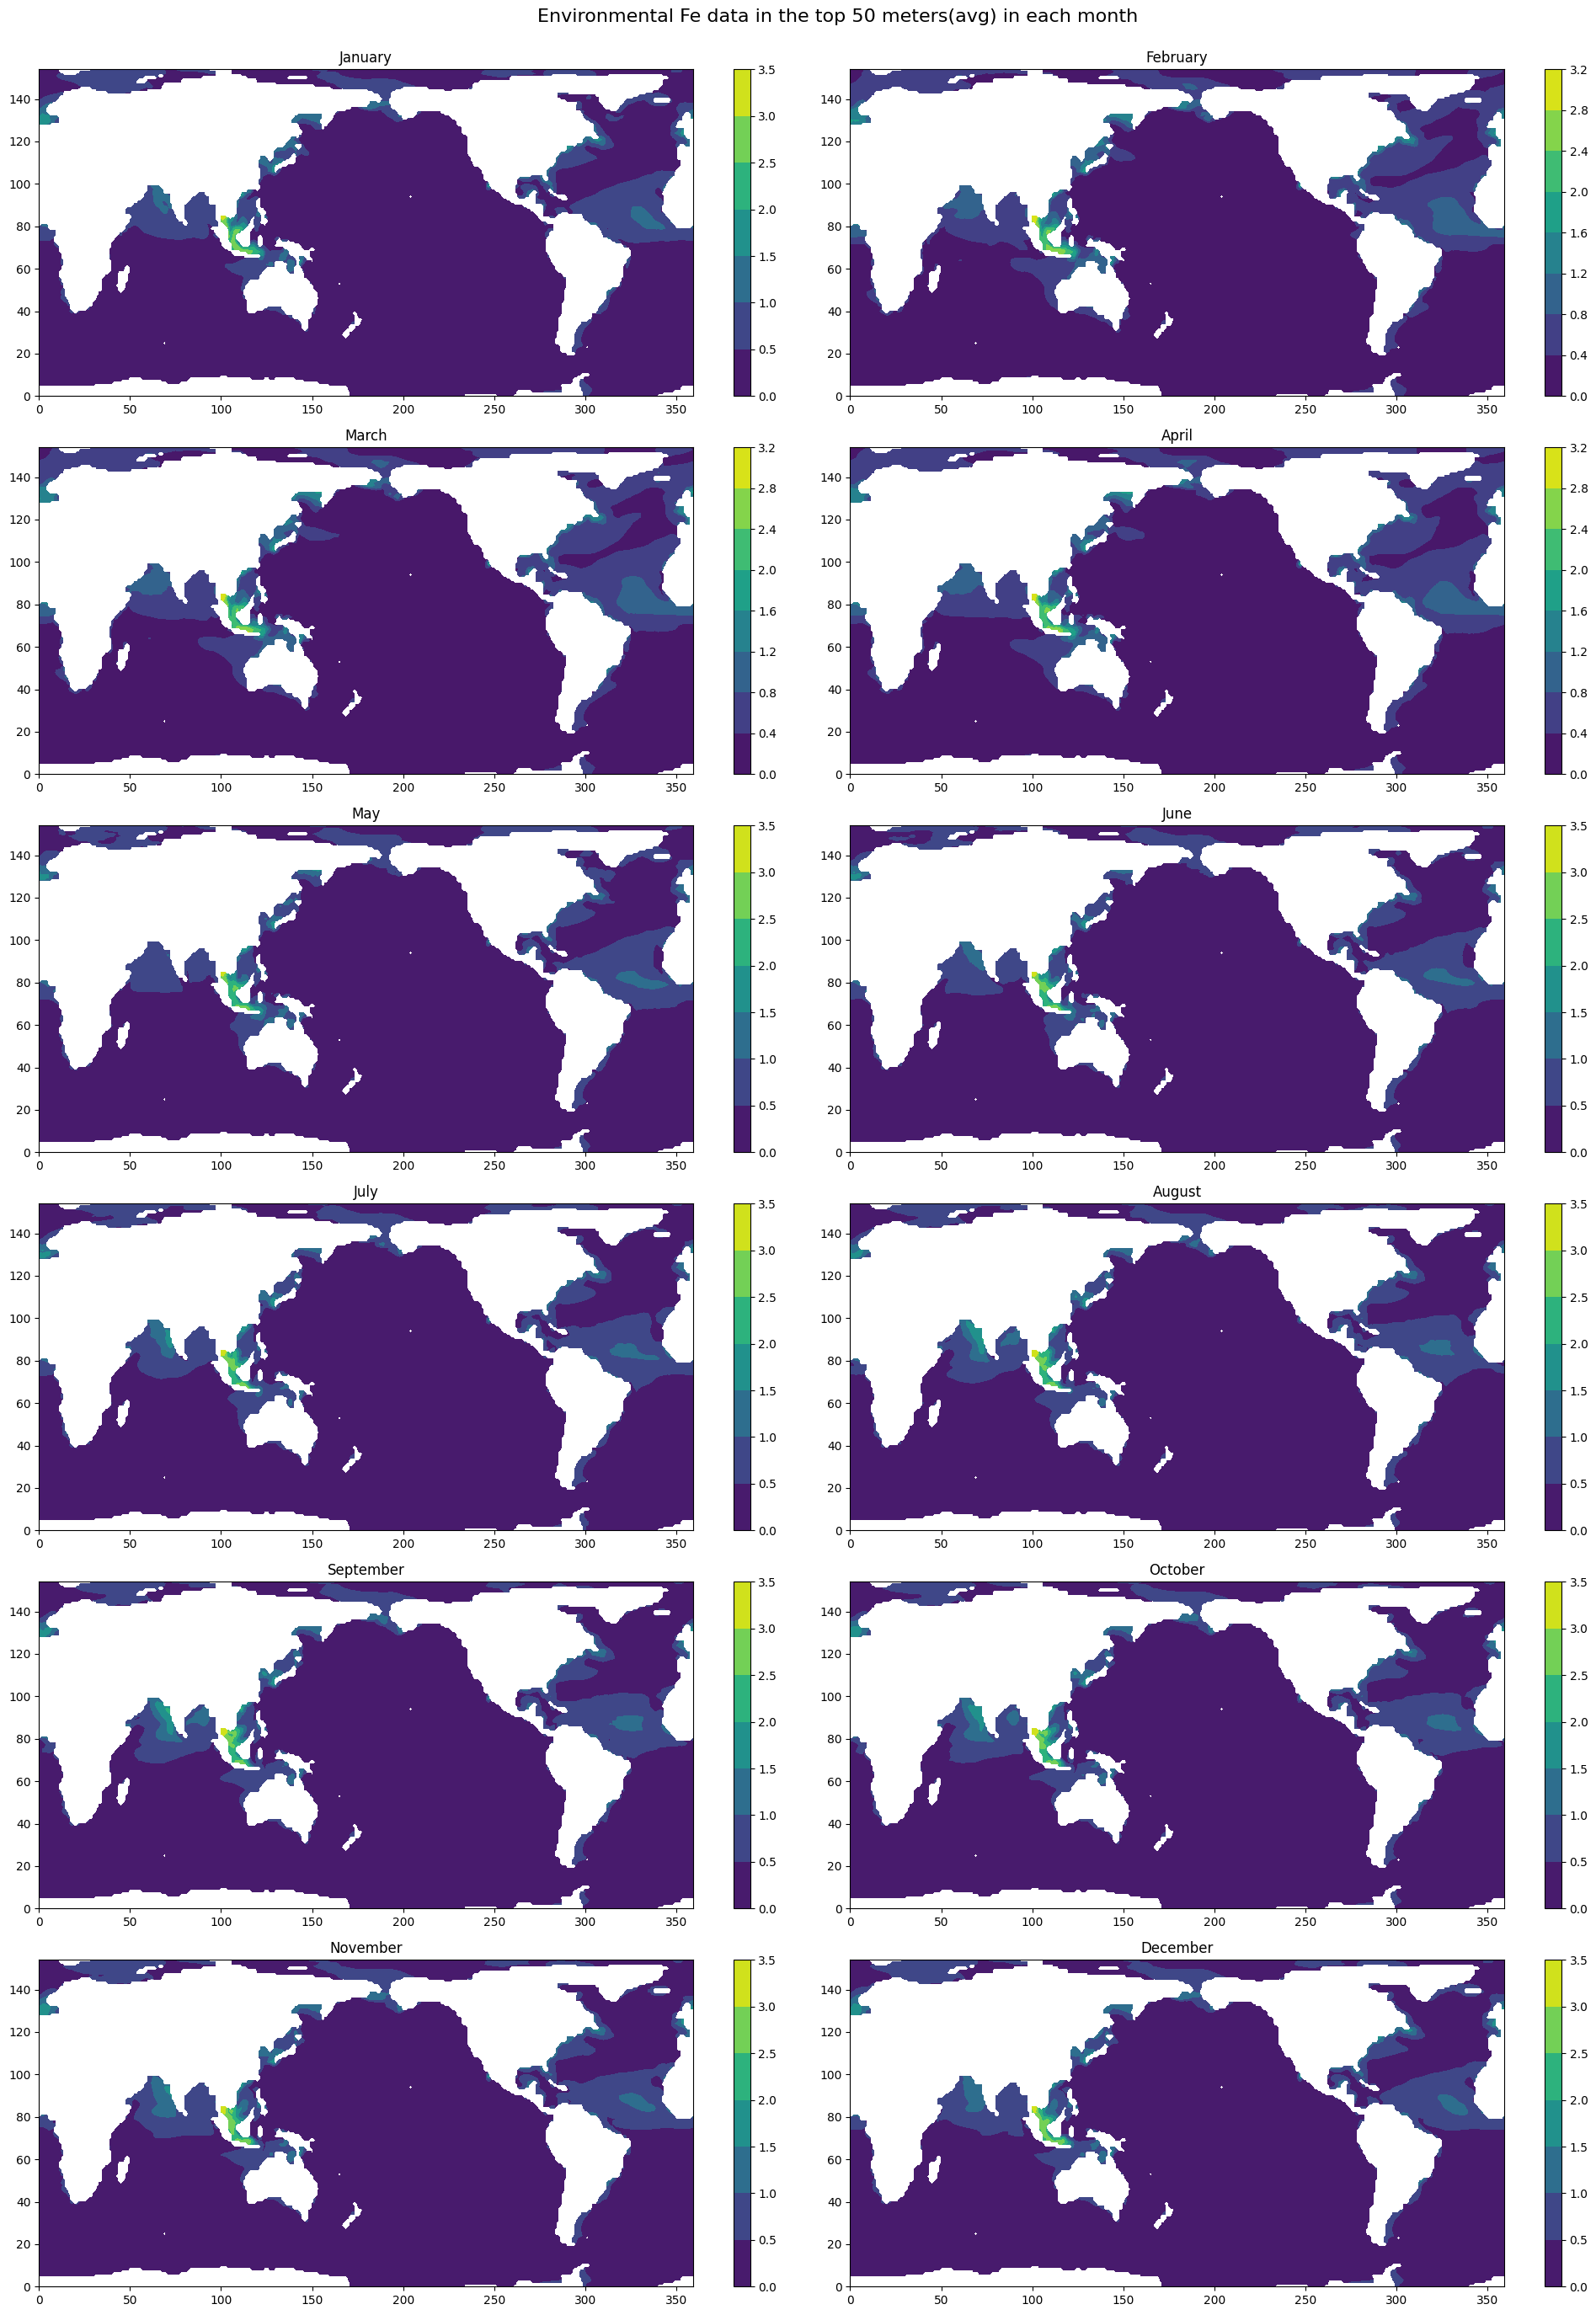

In [19]:
#the plot and plot data for visualization
figure, axes = plt.subplots(6, 2, figsize = (20,28))
axis = axes.flatten()
months = ["January","February","March","April","May","June","July","August","September","October","November","December"]

#we transofrm the data
Fe_array_fltrd = [el['dFe'].sel(DEPTH=slice(0, desired_depth)).isel(TIME=0) for el in Fe_array]

#we want to average out the data according to the depth in the desired range only for plotting
for i, month in enumerate(months):
    ax = axis[i]
    data  = Fe_array_fltrd[i].mean(dim='DEPTH')

    #then the data can be plotted
    title = month
    col = ax.contourf(data)
    ax.set_title(title)
    #adding the colorbar
    figure.colorbar(col, ax=ax, orientation='vertical')

figure.suptitle("Environmental Fe data in the top 50 meters(avg) in each month", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

Here it is clear that the range of values in the dataset is different from the range for other environmental variables as we can see by the 0 to 360 scale at the bottom of each plot.

Since initially data is separated based on months and we want just a combination of loaction+data value, we need to combine the xarray datasets into a single one along a new dinension MONTH

In [20]:
Fe_array_cnct = xr.concat(Fe_array_fltrd,dim="MONTH")
print(Fe_array_cnct)

<xarray.DataArray 'dFe' (MONTH: 12, DEPTH: 5, LATITUDE: 155, LONGITUDE: 360)> Size: 13MB
array([[[[       nan,        nan,        nan, ...,        nan,
                 nan,        nan],
         [       nan,        nan,        nan, ...,        nan,
                 nan,        nan],
         [       nan,        nan,        nan, ...,        nan,
                 nan,        nan],
         ...,
         [0.35699663, 0.3526645 , 0.35320142, ..., 0.3744387 ,
          0.36765608, 0.35982203],
         [0.35824203, 0.35066822, 0.34399098, ..., 0.40971965,
          0.38642538, 0.36968842],
         [0.3404093 , 0.3312948 , 0.3250679 , ..., 0.39324725,
          0.37082246, 0.35385606]],

        [[       nan,        nan,        nan, ...,        nan,
                 nan,        nan],
         [       nan,        nan,        nan, ...,        nan,
                 nan,        nan],
         [       nan,        nan,        nan, ...,        nan,
                 nan,        nan],
...
         

In order to make sure that all points are unique we group them by longitude and latitude, depth and take average.

In [21]:
Fe_array_avg = Fe_array_cnct.groupby(["LONGITUDE","LATITUDE","DEPTH"]).mean()
Fe_df = Fe_array_avg.to_dataframe().reset_index()

Fe_df.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 3348000 entries, 0 to 3347999
Data columns (total 6 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   MONTH      3348000 non-null  int64  
 1   LONGITUDE  3348000 non-null  float32
 2   LATITUDE   3348000 non-null  float32
 3   DEPTH      3348000 non-null  float32
 4   TIME       3348000 non-null  int32  
 5   dFe        2277600 non-null  float32
dtypes: float32(4), int32(1), int64(1)
memory usage: 89.4 MB


Not all columns are needed in further steps for training the model, so redundant columns are removed. Some columns are renamed for simplicity or to match the common conventions.

In [22]:
#we want to remove redundant columns and rename the data column
removeRed(["LATITUDE", "LONGITUDE","DEPTH", "dFe"], Fe_df)
Fe_df.rename(columns={"dFe":"Fe", "DEPTH":"DEPTH (m)"}, inplace=True)
Fe_df.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 3348000 entries, 0 to 3347999
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   LONGITUDE  3348000 non-null  float32
 1   LATITUDE   3348000 non-null  float32
 2   DEPTH (m)  3348000 non-null  float32
 3   Fe         2277600 non-null  float32
dtypes: float32(4)
memory usage: 51.1 MB


#### Coordinate range
Here it's important that the longitude range is between 0 and 360, however, in the other datasource the range is from -180 to +180. Thus the merge would produce false data by joining datapoints that actually are completely different.

In [23]:
Fe_df.describe()

,LONGITUDE,LATITUDE,DEPTH (m),Fe
count,3.348000e+06,3.348000e+06,3.348000e+06,2.277600e+06
mean,1.800000e+02,2.500000e+00,2.500000e+01,2.490634e-01
std,1.039227e+02,4.474372e+01,1.414214e+01,2.832052e-01
min,5.000000e-01,-7.450000e+01,5.000000e+00,0.000000e+00
25%,9.025000e+01,-3.650000e+01,1.500000e+01,4.543183e-02
50%,1.800000e+02,2.500000e+00,2.500000e+01,1.784423e-01
75%,2.697500e+02,4.150000e+01,3.500000e+01,3.454675e-01
max,3.595000e+02,7.950000e+01,4.500000e+01,3.378975e+00


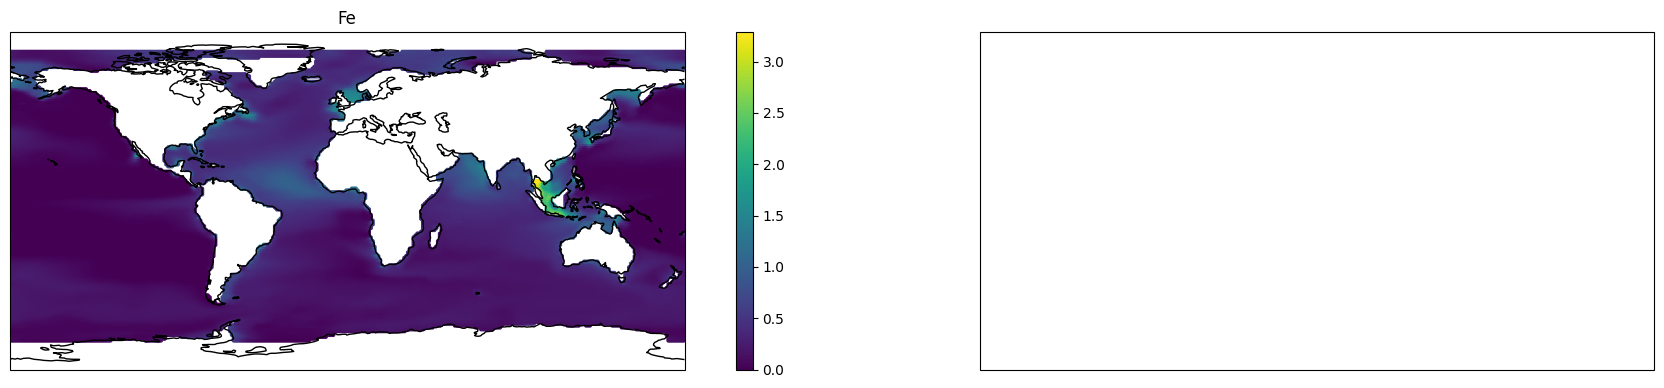

In [24]:
plotColsOnMap(["Fe"], Fe_df, constant=1)

In [25]:
conversion_mask = Fe_df["LONGITUDE"]>=180
Fe_df.loc[conversion_mask, "LONGITUDE"]=Fe_df["LONGITUDE"][conversion_mask]-np.ones(len(Fe_df["LONGITUDE"][conversion_mask]))*360
Fe_df.describe()

,LONGITUDE,LATITUDE,DEPTH (m),Fe
count,3.348000e+06,3.348000e+06,3.348000e+06,2.277600e+06
mean,0.000000e+00,2.500000e+00,2.500000e+01,2.490634e-01
std,1.039227e+02,4.474372e+01,1.414214e+01,2.832052e-01
min,-1.795000e+02,-7.450000e+01,5.000000e+00,0.000000e+00
25%,-8.975000e+01,-3.650000e+01,1.500000e+01,4.543183e-02
50%,0.000000e+00,2.500000e+00,2.500000e+01,1.784423e-01
75%,8.975000e+01,4.150000e+01,3.500000e+01,3.454675e-01
max,1.795000e+02,7.950000e+01,4.500000e+01,3.378975e+00


In [26]:
Fe_df.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 3348000 entries, 0 to 3347999
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   LONGITUDE  3348000 non-null  float32
 1   LATITUDE   3348000 non-null  float32
 2   DEPTH (m)  3348000 non-null  float32
 3   Fe         2277600 non-null  float32
dtypes: float32(4)
memory usage: 51.1 MB


### NaN values
Later on I noticed the presence of imputed data in the middle of the continent, which is not a thing that should happen. Especially as all the initial datasets don't seem to have data points there and this is ocean data.

So, I traced back the issue to the addition of Fe data and a high nan count in the dataset, that should be dealt with before joining. This can prevent the points in the middle of a landmass from appearing and then being filled.

In [27]:
Fe_df = removeEmptyRows(["Fe"], Fe_df)

Fe_df.info(show_counts=True)

<class 'pandas.DataFrame'>
Index: 2277600 entries, 25 to 3347999
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   LONGITUDE  2277600 non-null  float32
 1   LATITUDE   2277600 non-null  float32
 2   DEPTH (m)  2277600 non-null  float32
 3   Fe         2277600 non-null  float32
dtypes: float32(4)
memory usage: 52.1 MB


Before joining we need to make sure that all coordinates are unique

In [28]:
Fe_df = Fe_df.groupby(["LONGITUDE","LATITUDE","DEPTH (m)"]).mean().reset_index()
Fe_df = roundCoord(["Fe"], Fe_df, ["LONGITUDE","LATITUDE","DEPTH (m)"])
Fe_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 189800 entries, 0 to 189799
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   LONGITUDE  189800 non-null  int64  
 1   LATITUDE   189800 non-null  int64  
 2   DEPTH (m)  189800 non-null  int64  
 3   Fe         189800 non-null  float32
dtypes: float32(1), int64(3)
memory usage: 5.1 MB


In [29]:
depth_col = set(Fe_df["DEPTH (m)"])
print(depth_col)

{35, 5, 45, 15, 25}


We save the results into a csv file so we can later join it with the other features.

In [30]:
Fe_df[["LONGITUDE", "LATITUDE","DEPTH (m)","Fe"]].to_csv("../csv/features/Fe.csv", index=False)

## Next step, joining the data together:
Now we have a table for 4 features together(OTPN) and a table for solar and Iron data, but we want just 1 with all the environmental data in it. Thus, for each coordinate we want to merge the tables so that we have only 3 coordinate columns left and 6 columns of the environmental data.

After joining based on the latitude, longtitude and depth as indecies we count the number of null values to figure out the amount of cells we would need to fill. Since it is geographic data we should try to use close neighbours coordinates wise in order to fill the data that is missing. 

In [31]:
#we want to load back 2 datafreames and join them together
fe_dfs = pd.read_csv('../csv/features/Fe.csv')
fe_dfs.set_index(["LATITUDE", "LONGITUDE", "DEPTH (m)"],inplace=True)

otpn_df = pd.read_csv("../csv/features/OTPN.csv")
otpn_df = otpn_df.set_index(["LATITUDE", "LONGITUDE","DEPTH (m)"])
otpn_df.info()

#here the data is concatenated together, whcih creates a lot of nul values as this is not an inner join
env_data = otpn_df.join(fe_dfs, on=["LATITUDE", "LONGITUDE","DEPTH (m)"])

#here we display the combined data
env_data.reset_index(inplace=True)
env_data.describe()


<class 'pandas.DataFrame'>
MultiIndex: 898730 entries, (np.int64(-78), np.int64(-178), np.int64(0)) to (np.int64(90), np.int64(180), np.int64(50))
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   O2      898730 non-null  float64
 1   T       898730 non-null  float64
 2   P       898730 non-null  float64
 3   N       898730 non-null  float64
dtypes: float64(4)
memory usage: 30.9 MB


,LATITUDE,LONGITUDE,DEPTH (m),O2,T,P,N,Fe
count,1.969770e+06,1.969770e+06,1.969770e+06,1.969770e+06,1.969770e+06,1.969770e+06,1.969770e+06,1.439168e+06
mean,-5.685890e+00,-1.064488e+01,2.493869e+01,2.616889e+02,1.441910e+01,6.790304e-01,7.308835e+00,2.357779e-01
std,4.453540e+01,1.101123e+02,1.492092e+01,5.908008e+01,1.091871e+01,6.123195e-01,9.312783e+00,2.613589e-01
min,-7.800000e+01,-1.800000e+02,0.000000e+00,1.144983e+01,-1.888110e+00,3.282310e-03,0.000000e+00,0.000000e+00
25%,-4.400000e+01,-1.120000e+02,1.500000e+01,2.074633e+02,3.290300e+00,1.734654e-01,2.973512e-01,4.130366e-02
50%,-1.200000e+01,-2.000000e+01,2.500000e+01,2.470855e+02,1.628841e+01,4.260105e-01,2.180868e+00,1.755733e-01
75%,2.600000e+01,8.600000e+01,3.500000e+01,3.157231e+02,2.507230e+01,1.113728e+00,1.230585e+01,3.292919e-01
max,9.000000e+01,1.800000e+02,5.000000e+01,5.041048e+02,3.029479e+01,2.688223e+00,4.080209e+01,3.316630e+00


In [32]:
env_data.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 1969770 entries, 0 to 1969769
Data columns (total 8 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   LATITUDE   1969770 non-null  int64  
 1   LONGITUDE  1969770 non-null  int64  
 2   DEPTH (m)  1969770 non-null  int64  
 3   O2         1969770 non-null  float64
 4   T          1969770 non-null  float64
 5   P          1969770 non-null  float64
 6   N          1969770 non-null  float64
 7   Fe         1439168 non-null  float64
dtypes: float64(5), int64(3)
memory usage: 120.2 MB


### Observations based on histograms below:
The most null values are for Fe. T is the only feature that can take negative values. We can see that O2 has the most range, and P has the least. Thus, it would be a good idea to scale the features before the training. Median and average are somewhat close for all features, but further analsysis would require actually plotting the data.

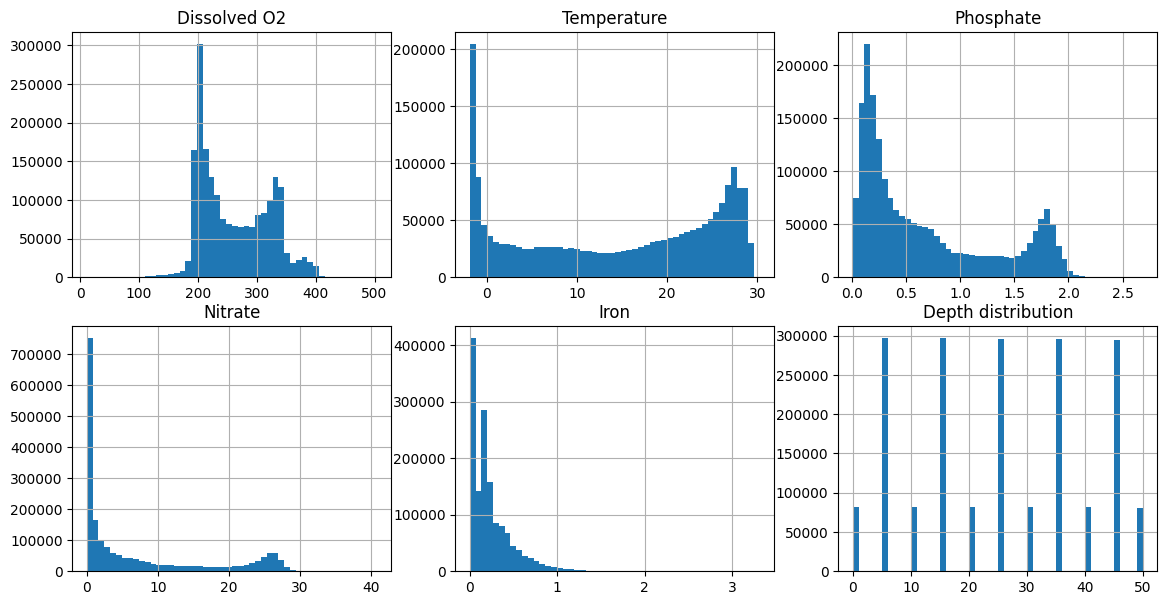

In [33]:
#I want to see the distributions of each variable to see what we are working with 
figure, axes = plt.subplots(2, 3, figsize = (14,7))
axis = axes.flatten()

map_plot_data2 = {
    "O2": "Dissolved O2",
    "T": "Temperature",
    "P": "Phosphate",
    "N": "Nitrate",
    "Fe":"Iron",
    "DEPTH (m)": "Depth distribution"
}
#this part actually shows the distributions
for i, feat in enumerate(map_plot_data2.keys()):
    ax=axis[i]
    title = map_plot_data2[feat]
    env_data[feat].hist(bins=50,ax=ax)
    ax.set_title(title)

plt.show()

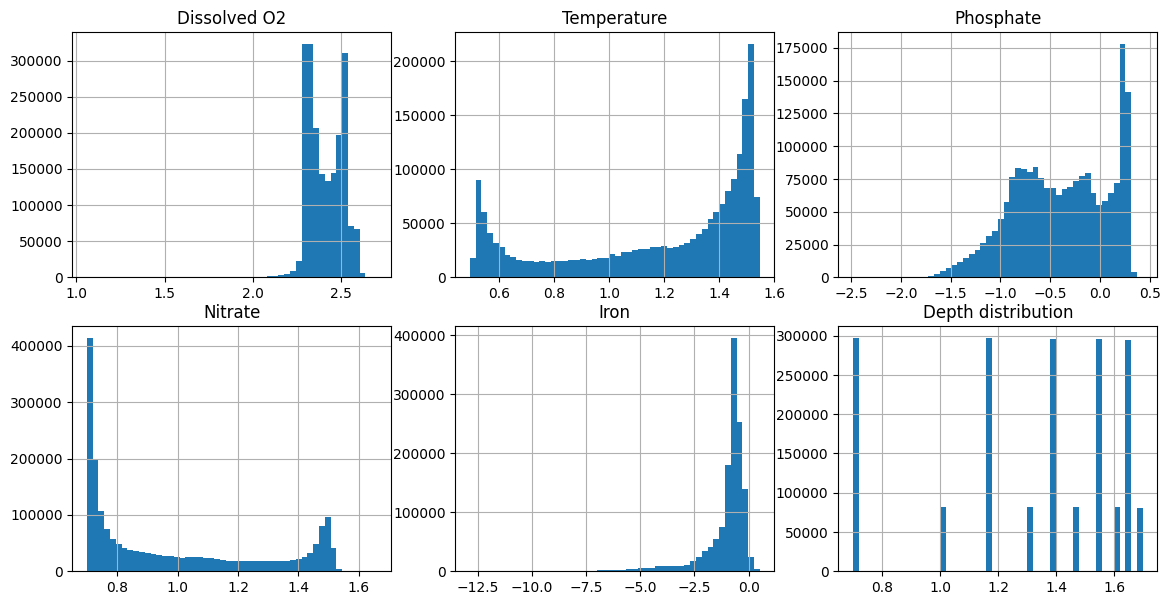

In [34]:
#Here we take a logarithm of each one of them to make sure 
figure, axes = plt.subplots(2, 3, figsize = (14,7))
axis = axes.flatten()

map_plot_data2 = {
    "O2": "Dissolved O2",
    "T": "Temperature",
    "P": "Phosphate",
    "N": "Nitrate",
    "Fe":"Iron",
    "DEPTH (m)": "Depth distribution"
}
#instead of just plotting the initial data we plot the logarithm while keeping track of values around 0
for i, feat in enumerate(map_plot_data2.keys()):
    #we figure out the axis and title
    title = map_plot_data2[feat]
    ax=axis[i]
    vals_skewed = env_data[feat].copy()
    #this is needed to make sure that the distributions that have negative values or a lot of values close to 0 are positive
    if(feat in ["T","N"]):
        vals_skewed = np.add(env_data[feat],5)
    log_vals = np.log10(vals_skewed[vals_skewed>0])
    log_vals.hist(bins=50,ax=ax)
    ax.set_title(title)

plt.show()

In [35]:
env_data_rnd = env_data
env_data_rnd.info(show_counts=True)
env_data.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1969770 entries, 0 to 1969769
Data columns (total 8 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   LATITUDE   1969770 non-null  int64  
 1   LONGITUDE  1969770 non-null  int64  
 2   DEPTH (m)  1969770 non-null  int64  
 3   O2         1969770 non-null  float64
 4   T          1969770 non-null  float64
 5   P          1969770 non-null  float64
 6   N          1969770 non-null  float64
 7   Fe         1439168 non-null  float64
dtypes: float64(5), int64(3)
memory usage: 120.2 MB


,LATITUDE,LONGITUDE,DEPTH (m),O2,T,P,N,Fe
count,1.969770e+06,1.969770e+06,1.969770e+06,1.969770e+06,1.969770e+06,1.969770e+06,1.969770e+06,1.439168e+06
mean,-5.685890e+00,-1.064488e+01,2.493869e+01,2.616889e+02,1.441910e+01,6.790304e-01,7.308835e+00,2.357779e-01
std,4.453540e+01,1.101123e+02,1.492092e+01,5.908008e+01,1.091871e+01,6.123195e-01,9.312783e+00,2.613589e-01
min,-7.800000e+01,-1.800000e+02,0.000000e+00,1.144983e+01,-1.888110e+00,3.282310e-03,0.000000e+00,0.000000e+00
25%,-4.400000e+01,-1.120000e+02,1.500000e+01,2.074633e+02,3.290300e+00,1.734654e-01,2.973512e-01,4.130366e-02
50%,-1.200000e+01,-2.000000e+01,2.500000e+01,2.470855e+02,1.628841e+01,4.260105e-01,2.180868e+00,1.755733e-01
75%,2.600000e+01,8.600000e+01,3.500000e+01,3.157231e+02,2.507230e+01,1.113728e+00,1.230585e+01,3.292919e-01
max,9.000000e+01,1.800000e+02,5.000000e+01,5.041048e+02,3.029479e+01,2.688223e+00,4.080209e+01,3.316630e+00


## Adding solar data
Since the data there is rounded it is added here. One thing to keep in mind is that the solar data is present all over the globe, while all other data is only present in the oceans. Thus, an inner join was used as then we only keep the ocean points that we care about without adding land into the mix.

In [36]:
#we open the solar data
solar_data = pd.read_csv("../csv/features/solar.csv")
solar_data.info(show_counts=True)

#we join the data and see the results
env_data_rnd = pd.merge(env_data_rnd, solar_data, on=["LATITUDE", "LONGITUDE"], how="inner")
env_data_rnd.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 65341 entries, 0 to 65340
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   LATITUDE   65341 non-null  int64  
 1   LONGITUDE  65341 non-null  int64  
 2   solar      65341 non-null  float64
dtypes: float64(1), int64(2)
memory usage: 1.5 MB
<class 'pandas.DataFrame'>
RangeIndex: 1975826 entries, 0 to 1975825
Data columns (total 9 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   LATITUDE   1975826 non-null  int64  
 1   LONGITUDE  1975826 non-null  int64  
 2   DEPTH (m)  1975826 non-null  int64  
 3   O2         1975826 non-null  float64
 4   T          1975826 non-null  float64
 5   P          1975826 non-null  float64
 6   N          1975826 non-null  float64
 7   Fe         1444228 non-null  float64
 8   solar      1975826 non-null  float64
dtypes: float64(6), int64(3)
memory usage: 135.7 MB


## Saving the data
Data is saved to a csv file for later steps

In [37]:
env_data_rnd.to_csv("../csv/features/env_data.csv", index=False)

env_data_rnd.describe()

,LATITUDE,LONGITUDE,DEPTH (m),O2,T,P,N,Fe,solar
count,1.975826e+06,1.975826e+06,1.975826e+06,1.975826e+06,1.975826e+06,1.975826e+06,1.975826e+06,1.444228e+06,1.975826e+06
mean,-5.690829e+00,-1.105118e+01,2.493891e+01,2.617499e+02,1.440107e+01,6.793435e-01,7.317749e+00,2.362368e-01,1.527234e+02
std,4.456032e+01,1.095417e+02,1.491995e+01,5.906114e+01,1.091352e+01,6.121472e-01,9.313503e+00,2.618983e-01,2.791681e+01
min,-7.800000e+01,-1.800000e+02,0.000000e+00,1.144983e+01,-1.888110e+00,3.282310e-03,0.000000e+00,0.000000e+00,7.855326e+01
25%,-4.400000e+01,-1.120000e+02,1.500000e+01,2.075293e+02,3.269510e+00,1.740894e-01,2.995195e-01,4.225958e-02,1.293318e+02
50%,-1.200000e+01,-2.000000e+01,2.500000e+01,2.472372e+02,1.625879e+01,4.271380e-01,2.198116e+00,1.755046e-01,1.543691e+02
75%,2.600000e+01,8.400000e+01,3.500000e+01,3.158121e+02,2.504371e+01,1.113223e+00,1.230046e+01,3.299320e-01,1.784812e+02
max,9.000000e+01,1.780000e+02,5.000000e+01,5.041048e+02,3.029479e+01,2.688223e+00,4.080209e+01,3.316630e+00,1.952198e+02


## Plotting data
This can take a while as there is a lot of it

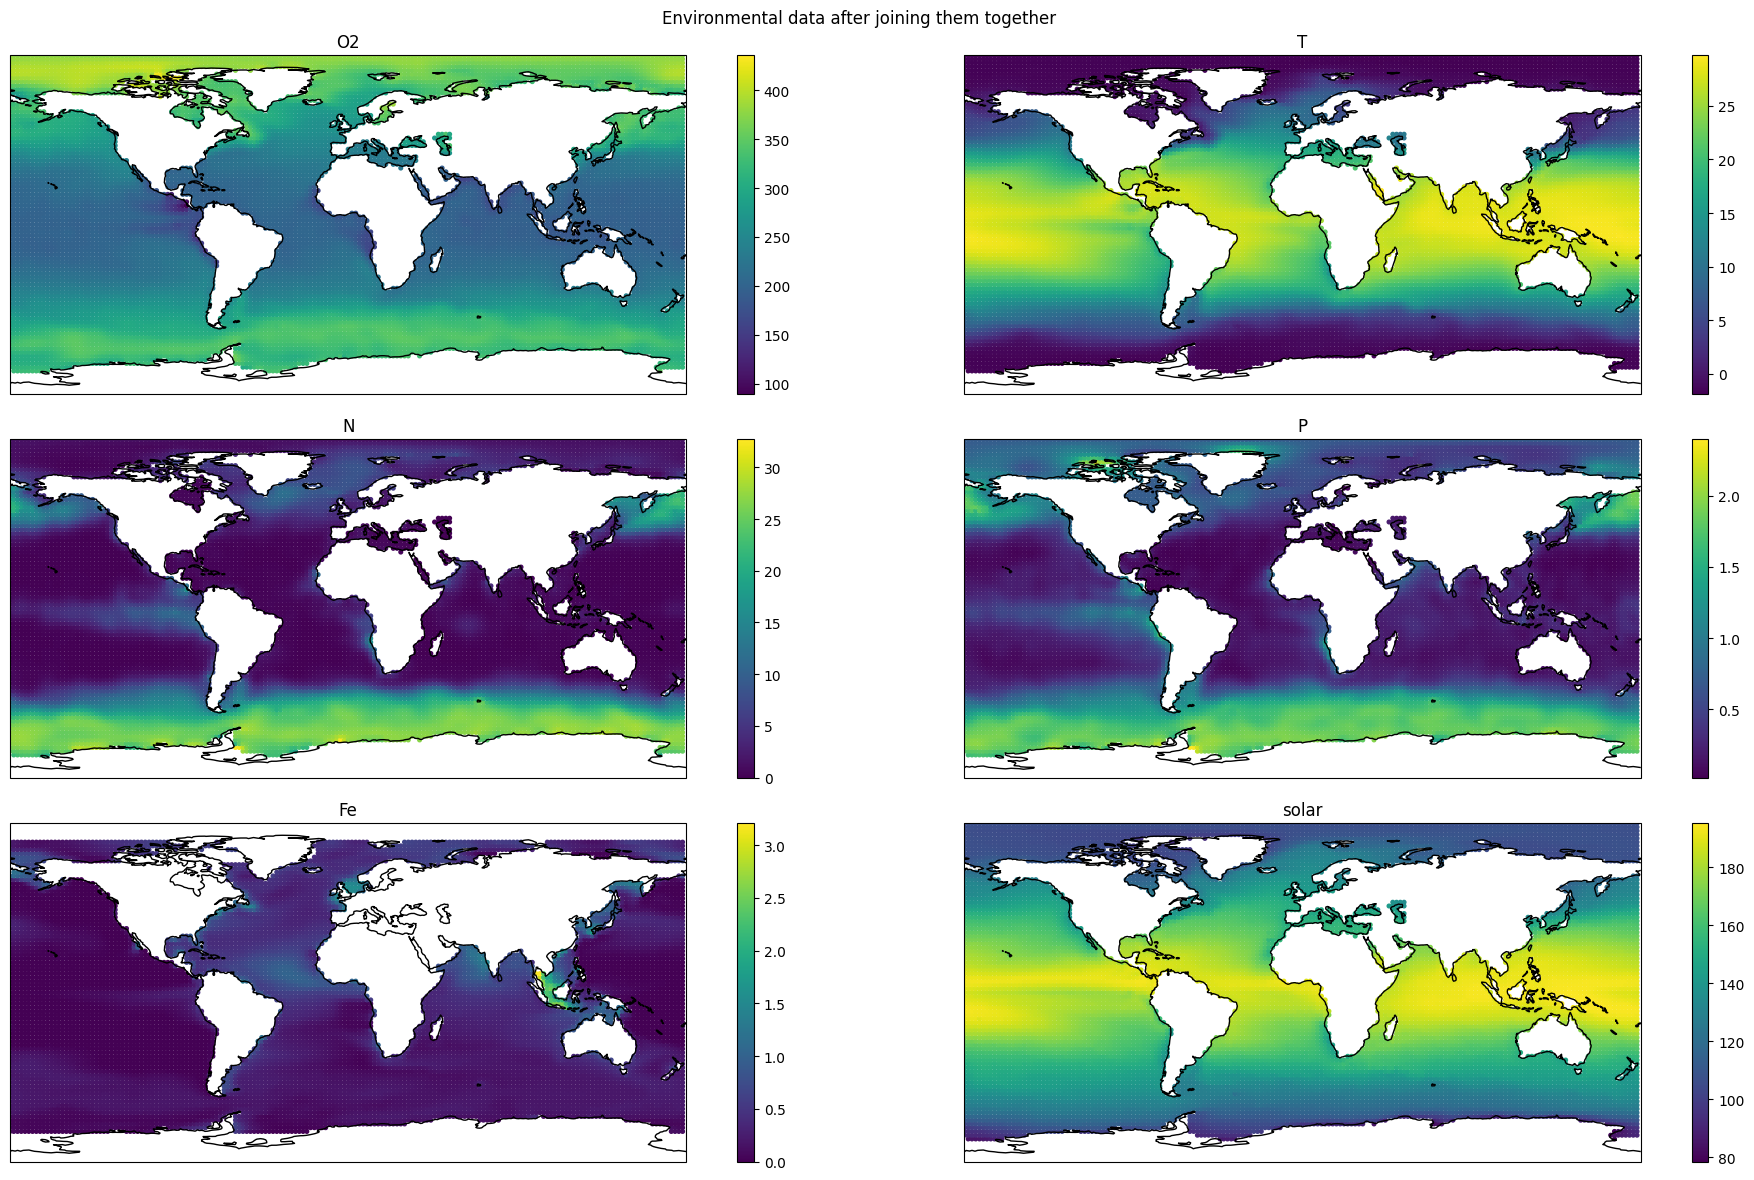

In [38]:
plotColsOnMap(["O2","T","N","P","Fe", "solar"], env_data_rnd, constant=1, title="Environmental data after joining them together", s=7)

## Conclusions:
Perhaps we should take logorithm of phosphate before putting it into the model as it made the distribution a lot less skewed. But I am doubtful on whether we should apply it to other values as some of them have a lot of values below 0 or don't seem to change nearly as much when we take the logorithm.

For other values we can try applying it and see if the model performs better as part of feature engineeting.

Also, unlike data about the bacteria the environmental data seems abundant and presetn almost for any coordinates on earth.